In [14]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

load_dotenv()

True

In [15]:
class EvaluatorResponse(BaseModel):
    text_feedback: str = Field(description="Textual feedback on the essay")
    score: int = Field(description="Score for the essay, between 0 and 10", ge=0, le=10)

class EssayState(TypedDict):
    essay_text: str
    grammar_feedback: str
    depth_analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    scores: Annotated[list[int], operator.add] #operator.add will sum up all the scores from different feedback nodes to calculate the final score
    final_score: float

In [16]:
model = ChatGroq(model="llama-3.3-70b-versatile")
structured_model = model.with_structured_output(EvaluatorResponse)


In [17]:
essay = """
Agentic AI the Rise of Autonmous Inteligence

Agentic ai is one of the most important development in technology today it is changing how machines works and how humans interact with them. Before, artificial inteligence was just a tool that answer question or do simple task. But now with agentic AI, systems can act by themself and make decision without always asking human what to do.

Agentic AI basically mean artificial intelligence that have agency. Agency means it can decide things and take action to reach some goal. Instead of just responding to prompt like normal chatbot does, it can plan steps, think about different options, and choose the best one (or sometimes not the best one). This makes it more powerfull but also more risky.

One important characteristic of agentic AI are autonomy. It dont need constant human instruction. Once you give it a goal, it try to achieve it by breaking it into smaller tasks. For example if you tell it to start a business online it could research market, design website, write content and even send emails. This show how advance these systems is becoming.

Another feature is planning and reasoning. The AI doesnt just react it actually evaluates situations. It may change its strategy if something goes wrong. However sometimes the reasoning are flawed because the data it learned from was bias or incomplete. Thats why supervision is still important.

There are many application of agentic AI in real world. In healthcare it could monitor patient and adjust treatments automaticly. In finance it may manage investement and trade stocks faster then humans. In companys it can automate workflow and increase productivity alot. Scientist also use AI agents to analyze experiment data and even generate new hypothesis which is very impressive.

But agentic AI also bring serious problem. One big issue is alignment. If the AI goal is not aligned with human values it might take action that are harmfull. For example if you tell it to maximize profit it might ignore ethics or safety. This is dangerous especially if the system control important infrastructure.

Another concern are accountability. When agentic AI make mistake who is responsible? The programmer, the company or the machine itself. Law and regulation is still not clear about this issue. Also security risk is growing because hackers could manipulate autonomous agents to do bad things.

In conclusion agentic AI represent a new era of intelligent system. It is more then just a tool it is almost like a digital worker that can think and act. Even though it have many benefits such as efficiency and scalability, it also create ethical and social challenges that society must address carefuly. If developed responsible, agentic AI could improve human life, but if ignored it might cause serious consequence.
"""

In [18]:
def generate_grammar_feedback(state: EssayState) -> EssayState:
    response = structured_model.invoke(f"Provide grammar feedback for the following essay:\n\n{state['essay_text']} and provide a score between 0 and 10 for the grammar quality.")
    return {"grammar_feedback": response.text_feedback, "scores": [response.score]}

In [19]:
def generate_clarity_feedback(state: EssayState) -> EssayState:
    response = structured_model.invoke(f"Provide clarity feedback for the following essay:\n\n{state['essay_text']} and provide a score between 0 and 10 for the clarity.")
    return {"clarity_feedback": response.text_feedback, "scores": [response.score]}

In [20]:
def generate_depth_analysis_feedback(state: EssayState) -> EssayState:
    response = structured_model.invoke(f"Provide depth of analysis feedback for the following essay:\n\n{state['essay_text']} and provide a score between 0 and 10 for the depth of analysis.")
    return {"depth_analysis_feedback": response.text_feedback, "scores": [response.score]}

In [21]:
def generate_overall_feedback(state: EssayState) -> EssayState:
    response = model.invoke(f"Provide overall feedback for the essay based on the grammar feedback: {state['grammar_feedback']}, depth analysis feedback: {state['depth_analysis_feedback']}, and clarity feedback: {state['clarity_feedback']}.")
    return {"overall_feedback": response.content}


In [22]:
def calculate_final_score(state: EssayState) -> EssayState:
    # The final score is calculated by summing the scores from grammar, clarity, and depth analysis feedback
    final_score = sum(state['scores']) / len(state['scores'])  # Average score
    return {"final_score": final_score}

In [23]:
graph = StateGraph(EssayState)

graph.add_node("grammar_feedback", generate_grammar_feedback)
graph.add_node("depth_analysis_feedback", generate_depth_analysis_feedback)
graph.add_node("clarity_feedback", generate_clarity_feedback)
graph.add_node("overall_feedback", generate_overall_feedback)
graph.add_node("final_score", calculate_final_score)


graph.add_edge(START, "grammar_feedback")
graph.add_edge(START, "depth_analysis_feedback")
graph.add_edge(START, "clarity_feedback")
graph.add_edge("grammar_feedback", "overall_feedback")
graph.add_edge("depth_analysis_feedback", "overall_feedback")
graph.add_edge("clarity_feedback", "overall_feedback")
graph.add_edge("overall_feedback", "final_score")
graph.add_edge("final_score", END)

In [24]:
workflow = graph.compile()

initial_state = {
    "essay_text": essay
}
final_state = workflow.invoke(initial_state)
print("Final State:", final_state)


Final State: {'essay_text': '\nAgentic AI the Rise of Autonmous Inteligence\n\nAgentic ai is one of the most important development in technology today it is changing how machines works and how humans interact with them. Before, artificial inteligence was just a tool that answer question or do simple task. But now with agentic AI, systems can act by themself and make decision without always asking human what to do.\n\nAgentic AI basically mean artificial intelligence that have agency. Agency means it can decide things and take action to reach some goal. Instead of just responding to prompt like normal chatbot does, it can plan steps, think about different options, and choose the best one (or sometimes not the best one). This makes it more powerfull but also more risky.\n\nOne important characteristic of agentic AI are autonomy. It dont need constant human instruction. Once you give it a goal, it try to achieve it by breaking it into smaller tasks. For example if you tell it to start a b

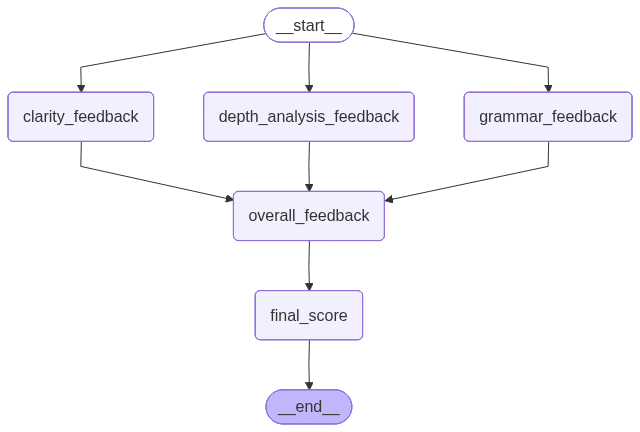

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
